In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Understand data structure.

In [4]:
# Load the dataset
df = pd.read_csv("/Users/harrish/Documents/Titanic_ML_Project/notebook/data/Titanic Dataset.csv")


In [5]:
# Checking head()
df.head(10)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.00,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.00,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39.00,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.00,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.00,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"


In [ ]:
# Checking the some data and try to run the loc and iloc fuction to get data.
 
# df.loc[0, 'age']
# df.iloc[0,4]

np.float64(29.0)

In [85]:
# Understanding of the data
print(df.shape)
df.tail()

(1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1304,3,0,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN
1308,3,0,"Zimmerman, Mr. Leo",male,29.0,0,0,315082,7.8750,NaN,S,NaN,NaN,NaN


In [86]:
print(df.info())
print(f"columns name of the data {df.columns}")

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(3), int64(4), str(7)
memory usage: 143.3 KB
None
columns name of the data Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='str')


In [87]:
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [88]:
# Checking categorical features and numerical features

categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical columns: {categorical_columns}")
print(f"Numerical columns : {numerical_columns}")

Categorical columns: Index(['name', 'sex', 'ticket', 'cabin', 'embarked', 'boat', 'home.dest'], dtype='str')
Numerical columns : Index(['pclass', 'survived', 'age', 'sibsp', 'parch', 'fare', 'body'], dtype='str')


# Data Cleaning 

### 1 missing values

In [89]:
# Checking the sum of the missing values in the dataset.

df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

<Axes: >

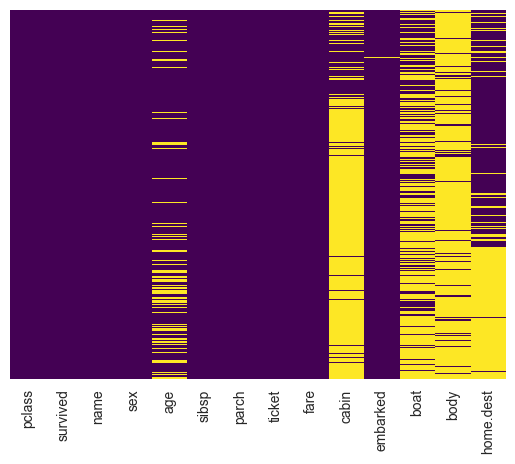

In [91]:
# Checking nall values using vizualization
sns.heatmap(df.isnull(),yticklabels=False, cbar=False, cmap='viridis')

In [93]:
pd.isnull(df['age'])

0       False
1       False
2       False
3       False
4       False
        ...  
1304    False
1305     True
1306    False
1307    False
1308    False
Name: age, Length: 1309, dtype: bool

In [94]:
# Handle missingd values
df['age'] = df['age'].fillna(df['age'].mean())

<Axes: >

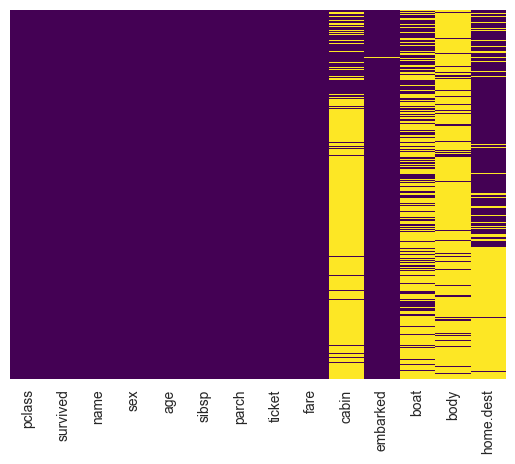

In [95]:
sns.heatmap(df.isnull(),yticklabels=False, cbar=False, cmap='viridis')

<Axes: xlabel='age', ylabel='Count'>

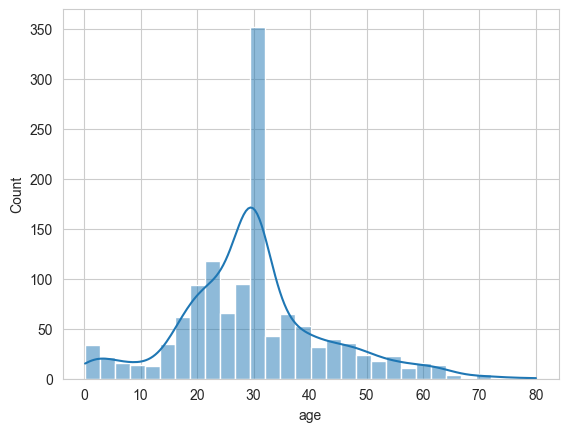

In [96]:
# some visualizations
sns.histplot(data=df, x='age', bins=30, kde=True)

<Axes: xlabel='survived', ylabel='count'>

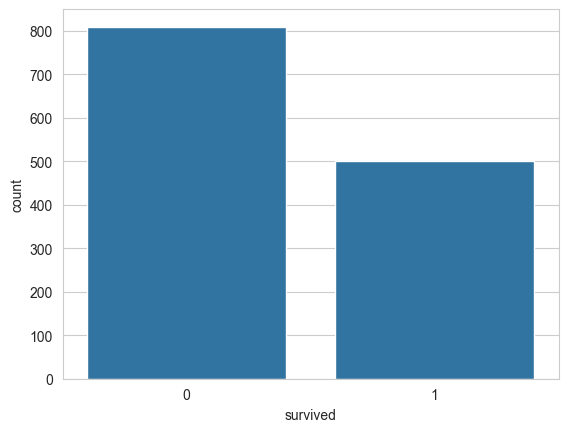

In [97]:
sns.countplot(x='survived', data=df)

<Axes: xlabel='survived', ylabel='count'>

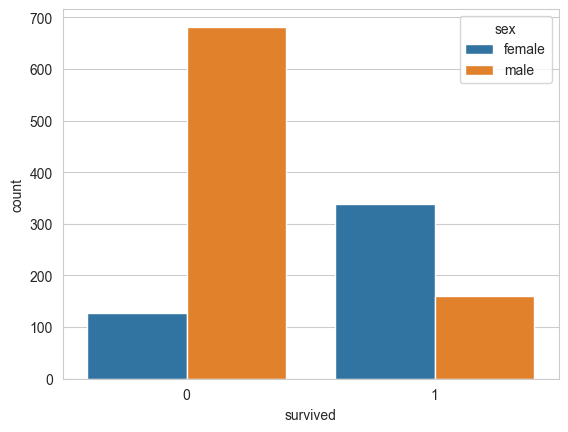

In [98]:
sns.countplot(x='survived', hue='sex', data=df)

<Axes: xlabel='survived', ylabel='count'>

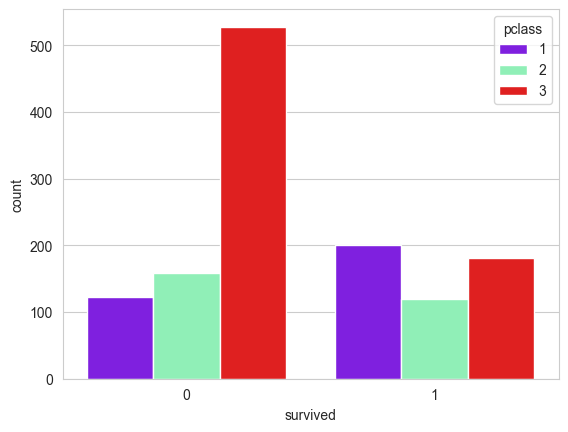

In [99]:
sns.set_style('whitegrid')
sns.countplot(x='survived',hue='pclass',data=df,palette='rainbow')

<Axes: xlabel='pclass', ylabel='age'>

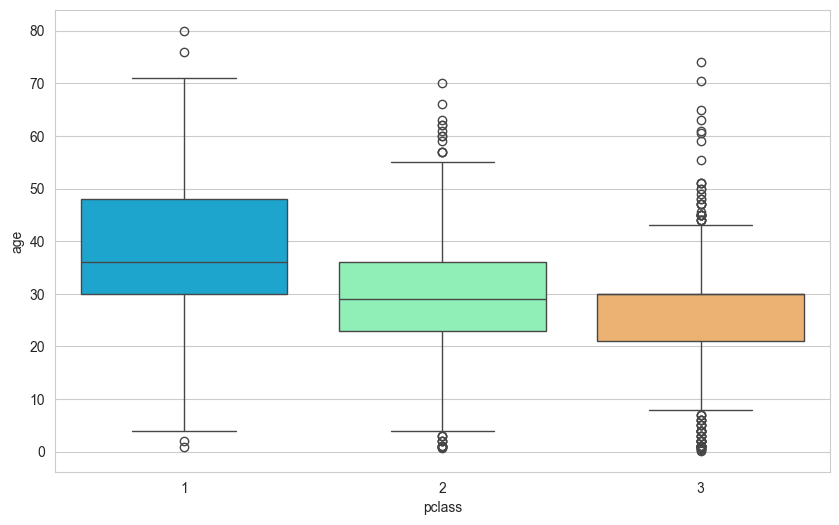

In [100]:
plt.figure(figsize=(10,6))
sns.boxplot(x='pclass',y='age',data=df,palette='rainbow')

<Axes: xlabel='age', ylabel='fare'>

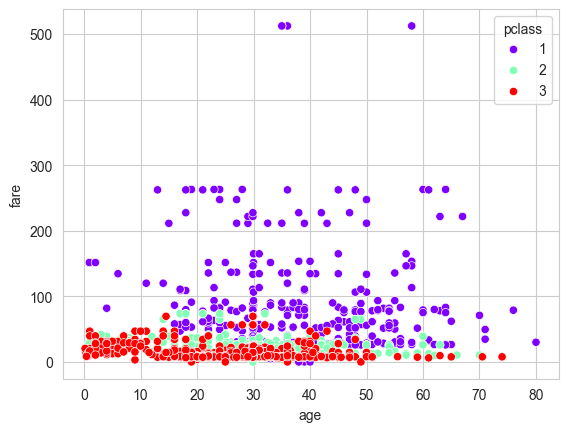

In [101]:
sns.scatterplot(x='age',y='fare',data=df,hue='pclass',palette='rainbow')

In [102]:
df.head(2)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"


# 2. Checking duplicated values

In [103]:
# Checking duplicate values
df.duplicated().sum()

np.int64(0)

# 3. Categorical data 

In [104]:
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical columns: {categorical_columns}")
print(f"Numerical columns : {numerical_columns}")   

Categorical columns: Index(['name', 'sex', 'ticket', 'cabin', 'embarked', 'boat', 'home.dest'], dtype='str')
Numerical columns : Index(['pclass', 'survived', 'age', 'sibsp', 'parch', 'fare', 'body'], dtype='str')


In [105]:
print(df['sex'].value_counts())
print(df['sex'].unique())

sex
male      843
female    466
Name: count, dtype: int64
<StringArray>
['female', 'male']
Length: 2, dtype: str


In [109]:
print(df['embarked'].value_counts())
print(df['embarked'].nunique())
print(f"{df['embarked'].isnull().sum()}")
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
print(df['embarked'].isnull().sum())

embarked
S    914
C    270
Q    123
Name: count, dtype: int64
3
2
0


In [110]:
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        0
boat          823
body         1188
home.dest     564
dtype: int64

In [111]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### 3.1 Converting categorical features

In [119]:
# Dealing with sex column
df['sex'] = df['sex'].replace({'male':0, 'female':1})

# Also we can used one hot encoding for numerical repersentation.

In [ ]:
# Dealing with embarked column
# But this time i am using one hot encoding for numerical repersentation.
embark = pd.get_dummies(df['embarked'], drop_first=True)
df = pd.concat([df, embark], axis=1)

In [122]:
df.head(1)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,Q,S
0,1,1,"Allen, Miss. Elisabeth Walton",1,29.0,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",False,True


# Removing unwanted columns

In [124]:
df.drop(['name', 'ticket','cabin', 'embarked','boat','body','home.dest'], axis=1, inplace=True)

In [135]:
df = df*1
df.head()

,pclass,survived,sex,age,sibsp,parch,fare,Q,S
0,1.0,1.0,1.0,29.00,0.0,0.0,211.3375,0.0,1.0
1,1.0,1.0,0.0,0.92,1.0,2.0,151.5500,0.0,1.0
2,1.0,0.0,1.0,2.00,1.0,2.0,151.5500,0.0,1.0
3,1.0,0.0,0.0,30.00,1.0,2.0,151.5500,0.0,1.0
4,1.0,0.0,1.0,25.00,1.0,2.0,151.5500,0.0,1.0


# Saving Data for the model training.

In [138]:
df.to_csv("/Users/harrish/Documents/Titanic_ML_Project/notebook/data/clean_Titanic_Dataset.csv", index=False)

Harish
22
Bangalore
Data Scientist
1
Python
Fraud Detection
English
Active
India
